### 2022년도 서울 지하철 열차 내부 혼잡도를 분석해보자!
- 서울교통공사에서 제공하는 2022년 1년간 지하철 1~8호선 라인 역들의 30분단위 평균 혼잡도 데이터
- 혼잡도는 정원대비 승차인원으로, 승차인과 좌석수가 일치할 경우를 혼잡도 34%로 산정함

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 데이터로드

In [4]:
data = pd.read_csv("data/서울교통공사_지하철혼잡도정보_20221231.csv",encoding="euc-kr")
data

,연번,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,1,평일,1,150,서울역,상선,7.3,18.1,18.1,30.9,...,15.6,17.1,17.7,14.9,13.7,17.2,10.4,8.8,8.8,1.2
1,2,평일,1,150,서울역,하선,11.5,11.0,13.2,21.4,...,35.3,36.1,35.0,29.4,39.2,26.1,17.1,11.8,8.5,0.0
2,3,평일,1,151,시청,상선,6.6,15.4,14.7,25.0,...,19.1,20.7,21.8,17.5,18.5,18.4,14.9,11.5,7.0,2.8
3,4,평일,1,151,시청,하선,9.0,9.1,14.6,20.0,...,30.5,32.4,31.1,28.5,30.2,22.2,15.4,10.1,6.5,0.8
4,5,평일,1,152,종각,상선,6.3,14.4,10.7,17.6,...,26.8,25.2,29.7,22.6,26.1,24.0,19.7,14.6,9.6,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,1654,공휴일,8,2827,모란,하선,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1634,1655,공휴일,8,2828,남위례,상선,9.9,5.8,6.6,8.1,...,7.3,6.1,7.5,6.5,5.0,4.2,3.5,2.0,NaN,NaN
1635,1656,공휴일,8,2828,남위례,하선,2.1,3.0,3.7,3.0,...,17.1,16.6,22.8,19.0,18.8,14.8,15.7,10.0,NaN,NaN
1636,1657,공휴일,8,2828,남위례,상선,9.9,5.8,6.6,8.1,...,7.3,6.1,7.5,6.5,5.0,4.2,3.5,2.0,NaN,NaN


In [5]:
# 데이터 프레임 모든 열 출력(출력되는 열 수 지정 가능, None은 모든 컬럼 출력)
pd.set_option('display.max_columns',None)

In [6]:
data

,연번,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,1,평일,1,150,서울역,상선,7.3,18.1,18.1,30.9,56.6,69.1,82.7,57.5,52.3,36.9,31.8,30.9,30.9,25.8,39.2,29.6,30.5,28.2,22.9,25.4,24.0,22.4,25.7,24.1,35.6,42.8,39.1,28.3,21.3,15.6,17.1,17.7,14.9,13.7,17.2,10.4,8.8,8.8,1.2
1,2,평일,1,150,서울역,하선,11.5,11.0,13.2,21.4,38.0,38.7,24.6,24.0,19.8,18.8,21.0,19.4,19.5,23.3,27.2,27.6,27.0,34.2,28.7,42.3,35.6,48.7,54.5,62.7,70.2,107.8,82.2,46.5,37.1,35.3,36.1,35.0,29.4,39.2,26.1,17.1,11.8,8.5,0.0
2,3,평일,1,151,시청,상선,6.6,15.4,14.7,25.0,42.4,55.0,56.0,44.3,48.2,30.5,29.8,29.2,28.6,26.2,36.6,30.8,29.1,28.6,25.3,27.4,24.6,24.3,28.3,26.5,39.2,58.1,47.5,33.2,24.7,19.1,20.7,21.8,17.5,18.5,18.4,14.9,11.5,7.0,2.8
3,4,평일,1,151,시청,하선,9.0,9.1,14.6,20.0,35.4,35.7,26.9,26.0,20.6,18.9,19.7,18.6,18.2,22.3,24.8,26.8,26.2,32.3,29.4,38.3,37.6,42.7,44.7,59.6,62.9,105.5,74.2,40.7,32.2,30.5,32.4,31.1,28.5,30.2,22.2,15.4,10.1,6.5,0.8
4,5,평일,1,152,종각,상선,6.3,14.4,10.7,17.6,26.7,36.0,31.2,28.0,36.5,27.4,24.8,26.4,26.4,25.9,31.8,29.6,28.9,30.2,26.6,30.1,27.8,28.0,30.4,33.7,41.8,76.1,54.9,39.6,28.9,26.8,25.2,29.7,22.6,26.1,24.0,19.7,14.6,9.6,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,1654,공휴일,8,2827,모란,하선,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1634,1655,공휴일,8,2828,남위례,상선,9.9,5.8,6.6,8.1,10.5,14.7,17.0,21.9,22.5,22.2,21.3,20.6,20.8,23.7,22.7,21.4,20.9,19.8,19.3,19.3,20.0,17.9,17.4,15.8,14.0,12.5,11.3,8.0,8.2,7.3,6.1,7.5,6.5,5.0,4.2,3.5,2.0,NaN,NaN
1635,1656,공휴일,8,2828,남위례,하선,2.1,3.0,3.7,3.0,4.0,4.8,5.7,7.5,9.0,9.9,5.0,7.5,9.8,9.5,11.2,11.6,13.6,12.3,13.2,15.2,14.7,17.3,17.4,20.3,19.4,20.2,21.1,19.7,17.0,17.1,16.6,22.8,19.0,18.8,14.8,15.7,10.0,NaN,NaN
1636,1657,공휴일,8,2828,남위례,상선,9.9,5.8,6.6,8.1,10.5,14.7,17.0,21.9,22.5,22.2,21.3,20.6,20.8,23.7,22.7,21.4,20.9,19.8,19.3,19.3,20.0,17.9,17.4,15.8,14.0,12.5,11.3,8.0,8.2,7.3,6.1,7.5,6.5,5.0,4.2,3.5,2.0,NaN,NaN


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638 entries, 0 to 1637
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      1638 non-null   int64  
 1   요일구분    1638 non-null   object 
 2   호선      1638 non-null   int64  
 3   역번호     1638 non-null   int64  
 4   출발역     1638 non-null   object 
 5   상하구분    1638 non-null   object 
 6   5시30분   1612 non-null   float64
 7   6시00분   1638 non-null   float64
 8   6시30분   1638 non-null   float64
 9   7시00분   1638 non-null   float64
 10  7시30분   1638 non-null   float64
 11  8시00분   1638 non-null   float64
 12  8시30분   1638 non-null   float64
 13  9시00분   1638 non-null   float64
 14  9시30분   1638 non-null   float64
 15  10시00분  1638 non-null   float64
 16  10시30분  1638 non-null   float64
 17  11시00분  1638 non-null   float64
 18  11시30분  1638 non-null   float64
 19  12시00분  1638 non-null   float64
 20  12시30분  1638 non-null   float64
 21  13시00분  1638 non-null   float64
 22  

### 데이터 파악 및 가공

In [8]:
# 데이터가 부족한 컬럼들은 없어도 큰 문제가 안될 것 같으니 삭제하자!
data.drop(["5시30분","23시30분","00시00분","00시30분"], axis=1, inplace=True)

In [9]:
data

,연번,요일구분,호선,역번호,출발역,상하구분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
0,1,평일,1,150,서울역,상선,18.1,18.1,30.9,56.6,69.1,82.7,57.5,52.3,36.9,31.8,30.9,30.9,25.8,39.2,29.6,30.5,28.2,22.9,25.4,24.0,22.4,25.7,24.1,35.6,42.8,39.1,28.3,21.3,15.6,17.1,17.7,14.9,13.7,17.2,10.4
1,2,평일,1,150,서울역,하선,11.0,13.2,21.4,38.0,38.7,24.6,24.0,19.8,18.8,21.0,19.4,19.5,23.3,27.2,27.6,27.0,34.2,28.7,42.3,35.6,48.7,54.5,62.7,70.2,107.8,82.2,46.5,37.1,35.3,36.1,35.0,29.4,39.2,26.1,17.1
2,3,평일,1,151,시청,상선,15.4,14.7,25.0,42.4,55.0,56.0,44.3,48.2,30.5,29.8,29.2,28.6,26.2,36.6,30.8,29.1,28.6,25.3,27.4,24.6,24.3,28.3,26.5,39.2,58.1,47.5,33.2,24.7,19.1,20.7,21.8,17.5,18.5,18.4,14.9
3,4,평일,1,151,시청,하선,9.1,14.6,20.0,35.4,35.7,26.9,26.0,20.6,18.9,19.7,18.6,18.2,22.3,24.8,26.8,26.2,32.3,29.4,38.3,37.6,42.7,44.7,59.6,62.9,105.5,74.2,40.7,32.2,30.5,32.4,31.1,28.5,30.2,22.2,15.4
4,5,평일,1,152,종각,상선,14.4,10.7,17.6,26.7,36.0,31.2,28.0,36.5,27.4,24.8,26.4,26.4,25.9,31.8,29.6,28.9,30.2,26.6,30.1,27.8,28.0,30.4,33.7,41.8,76.1,54.9,39.6,28.9,26.8,25.2,29.7,22.6,26.1,24.0,19.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,1654,공휴일,8,2827,모란,하선,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1634,1655,공휴일,8,2828,남위례,상선,5.8,6.6,8.1,10.5,14.7,17.0,21.9,22.5,22.2,21.3,20.6,20.8,23.7,22.7,21.4,20.9,19.8,19.3,19.3,20.0,17.9,17.4,15.8,14.0,12.5,11.3,8.0,8.2,7.3,6.1,7.5,6.5,5.0,4.2,3.5
1635,1656,공휴일,8,2828,남위례,하선,3.0,3.7,3.0,4.0,4.8,5.7,7.5,9.0,9.9,5.0,7.5,9.8,9.5,11.2,11.6,13.6,12.3,13.2,15.2,14.7,17.3,17.4,20.3,19.4,20.2,21.1,19.7,17.0,17.1,16.6,22.8,19.0,18.8,14.8,15.7
1636,1657,공휴일,8,2828,남위례,상선,5.8,6.6,8.1,10.5,14.7,17.0,21.9,22.5,22.2,21.3,20.6,20.8,23.7,22.7,21.4,20.9,19.8,19.3,19.3,20.0,17.9,17.4,15.8,14.0,12.5,11.3,8.0,8.2,7.3,6.1,7.5,6.5,5.0,4.2,3.5


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638 entries, 0 to 1637
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연번      1638 non-null   int64  
 1   요일구분    1638 non-null   object 
 2   호선      1638 non-null   int64  
 3   역번호     1638 non-null   int64  
 4   출발역     1638 non-null   object 
 5   상하구분    1638 non-null   object 
 6   6시00분   1638 non-null   float64
 7   6시30분   1638 non-null   float64
 8   7시00분   1638 non-null   float64
 9   7시30분   1638 non-null   float64
 10  8시00분   1638 non-null   float64
 11  8시30분   1638 non-null   float64
 12  9시00분   1638 non-null   float64
 13  9시30분   1638 non-null   float64
 14  10시00분  1638 non-null   float64
 15  10시30분  1638 non-null   float64
 16  11시00분  1638 non-null   float64
 17  11시30분  1638 non-null   float64
 18  12시00분  1638 non-null   float64
 19  12시30분  1638 non-null   float64
 20  13시00분  1638 non-null   float64
 21  13시30분  1638 non-null   float64
 22  

In [12]:
np.unique(data["연번"])

array([   1,    2,    3, ..., 1656, 1657, 1658], dtype=int64)

In [13]:
len(np.unique(data["연번"]))

1638

In [14]:
# value_counts : 컬럼에 들어있는 데이터의 유니크값 및 그 개수를 출력
data["요일구분"].value_counts()

array(['공휴일', '토요일', '평일'], dtype=object)

In [15]:
len(np.unique(data["요일구분"]))

3

In [16]:
data["호선"].value_counts()

5    336
2    306
7    252
6    214
3    204
4    162
8    104
1     60
Name: 호선, dtype: int64

In [17]:
data["역번호"].value_counts()

150     6
2624    6
2561    6
2562    6
2563    6
       ..
2615    2
2616    2
405     2
406     2
408     2
Name: 역번호, Length: 279, dtype: int64

In [18]:
data["출발역"].value_counts()

동대문역사문화공원    18
종로3가         18
서울역          12
사당           12
대림           12
             ..
역촌            2
독바위           2
신천            2
구산            2
별내별가람         2
Name: 출발역, Length: 243, dtype: int64

In [19]:
len(data["출발역"].value_counts())

243

In [20]:
data[data["출발역"]=="종로3가"]

,연번,요일구분,호선,역번호,출발역,상하구분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
6,7,평일,1,153,종로3가,상선,13.8,10.6,17.2,25.9,40.7,32.5,28.7,37.2,28.4,27.3,25.8,26.1,27.4,35.2,35.1,28.8,33.4,30.8,33.9,33.9,30.9,35.4,37.8,46.6,81.1,67.7,40.5,32.2,28.9,25.3,35.8,26.3,29.1,28.0,22.2
7,8,평일,1,153,종로3가,하선,9.1,19.6,28.7,58.3,61.2,72.0,48.9,36.2,23.6,25.2,20.4,21.3,23.8,24.8,25.8,26.9,29.8,27.7,35.0,30.7,36.3,37.5,39.8,47.1,54.7,42.1,23.5,20.5,17.5,18.9,17.2,15.3,16.8,11.7,8.4
142,143,평일,3,319,종로3가,상선,13.0,15.5,24.8,33.4,34.1,38.1,35.5,38.4,31.1,30.9,37.7,39.5,42.0,57.1,42.7,41.9,38.9,46.6,66.2,60.3,57.4,60.7,105.4,110.3,111.2,104.7,82.1,63.8,50.5,51.1,48.4,45.3,48.2,51.1,34.0
143,144,평일,3,319,종로3가,하선,30.0,38.7,50.8,74.9,104.3,82.6,65.4,56.3,46.3,45.6,41.1,35.1,36.9,38.4,48.9,47.1,39.2,36.7,37.6,48.6,64.1,55.5,42.0,46.5,67.8,39.1,26.3,18.5,16.9,17.2,19.1,20.5,18.5,15.2,12.7
290,291,평일,5,2535,종로3가,상선,21.4,27.1,52.6,73.9,89.4,73.4,44.8,37.9,27.4,27.4,27.9,26.4,26.9,29.1,30.2,28.6,28.1,27.7,28.7,31.4,33.8,41.0,45.1,46.7,43.7,38.8,32.6,29.5,24.2,23.0,23.2,22.4,22.5,19.0,14.9
291,292,평일,5,2535,종로3가,하선,15.6,14.9,21.2,31.1,38.5,22.5,17.3,16.8,15.9,18.2,20.8,20.5,22.9,23.4,25.9,24.0,27.7,26.6,30.5,33.6,39.8,46.1,62.1,65.9,80.7,70.4,55.7,46.0,38.4,37.1,39.4,38.0,34.2,29.5,22.6
558,559,토요일,1,153,종로3가,상선,13.1,11.9,13.7,12.1,20.1,21.9,18.6,26.2,27.0,30.9,30.0,39.8,43.0,39.4,45.2,35.2,32.4,50.6,41.5,42.3,34.7,44.2,39.1,35.2,37.9,29.0,23.3,29.2,24.3,23.5,27.7,29.1,28.3,26.5,23.5
559,560,토요일,1,153,종로3가,하선,11.6,10.0,11.2,14.8,13.9,18.9,23.6,25.9,26.9,28.4,25.1,32.1,31.9,41.7,40.4,38.0,46.6,46.2,48.2,48.0,35.8,49.7,48.4,45.8,42.8,33.6,28.3,26.7,23.0,19.0,19.7,18.8,16.3,13.0,10.5
694,695,토요일,3,319,종로3가,상선,10.8,8.9,10.9,14.8,19.1,27.4,36.2,45.6,45.1,43.2,44.7,59.4,48.2,54.5,58.4,61.1,54.8,61.1,59.6,58.0,68.9,59.9,74.8,64.1,60.2,62.1,49.3,37.6,42.9,52.9,44.6,43.1,49.3,36.9,35.6
695,696,토요일,3,319,종로3가,하선,17.3,13.9,15.6,20.5,33.4,35.2,40.6,42.8,38.0,39.5,44.1,42.3,44.7,46.8,35.1,47.0,44.7,52.5,48.9,56.1,56.8,61.4,65.7,56.3,48.8,37.7,34.1,26.9,23.7,21.7,23.4,17.2,26.1,15.8,13.3


In [22]:
data["상하구분"].value_counts()

상선    666
하선    666
내선    153
외선    153
Name: 상하구분, dtype: int64

#### ◆ 혼잡도가 가장 높은 역을 찾아보자!
- 연번 컬럼에서 상하구분 컬럼까지 분리하고. 전체 시간에서 혼잡도가 최대인 값을 구해서 '최대혼잡도'컬럼을 생선한 후, 이 둘을 합쳐보자!

In [23]:
left = data.loc[: ,"연번":"상하구분"]
left

,연번,요일구분,호선,역번호,출발역,상하구분
0,1,평일,1,150,서울역,상선
1,2,평일,1,150,서울역,하선
2,3,평일,1,151,시청,상선
3,4,평일,1,151,시청,하선
4,5,평일,1,152,종각,상선
...,...,...,...,...,...,...
1633,1654,공휴일,8,2827,모란,하선
1634,1655,공휴일,8,2828,남위례,상선
1635,1656,공휴일,8,2828,남위례,하선
1636,1657,공휴일,8,2828,남위례,상선


In [25]:
# DF에 max함수를 열 방향(axis=1, 좌에서 우측)으로 적용
right = data.loc[: , "6시00분":].max(axis=1)
right

0        82.7
1       107.8
2        58.1
3       105.5
4        76.1
        ...  
1633      0.0
1634     23.7
1635     22.8
1636     23.7
1637     22.8
Length: 1638, dtype: float64

In [27]:
# Series인 right에 이름 설정(concat시 컬럼명이 자동으로 설정되게 하기 위함)
right.name = "최대혼잡도"
right

0        82.7
1       107.8
2        58.1
3       105.5
4        76.1
        ...  
1633      0.0
1634     23.7
1635     22.8
1636     23.7
1637     22.8
Name: 최대혼잡도, Length: 1638, dtype: float64

In [28]:
max_con = pd.concat([left,right],axis=1)
max_con

# 최대 혼잡도가 0이라는 것은 1년간 아무도 열차에 ㅌ탑승하지 않았다는 것인데
# 1년간 열차 운행이 없었거나 아니면 잘못된 데이터라고 판단할 수 있음!
# (데이터에 대한 기본적인 이해가 있어야 값의 의미를 파악할 수 있음 -> 도메인 지식의 중요성)

,연번,요일구분,호선,역번호,출발역,상하구분,최대혼잡도
0,1,평일,1,150,서울역,상선,82.7
1,2,평일,1,150,서울역,하선,107.8
2,3,평일,1,151,시청,상선,58.1
3,4,평일,1,151,시청,하선,105.5
4,5,평일,1,152,종각,상선,76.1
...,...,...,...,...,...,...,...
1633,1654,공휴일,8,2827,모란,하선,0.0
1634,1655,공휴일,8,2828,남위례,상선,23.7
1635,1656,공휴일,8,2828,남위례,하선,22.8
1636,1657,공휴일,8,2828,남위례,상선,23.7


In [29]:
# 최대혼잡도 컬럼 내부 값 기준 내림차순 정렬
max_con = max_con.sort_values(by="최대혼잡도",ascending=False)
max_con

,연번,요일구분,호선,역번호,출발역,상하구분,최대혼잡도
209,210,평일,4,418,성신여대입구,하선,185.5
211,212,평일,4,419,한성대입구,하선,184.5
207,208,평일,4,417,길음,하선,176.2
71,72,평일,2,226,사당,외선,172.3
213,214,평일,4,420,혜화,하선,171.5
...,...,...,...,...,...,...,...
672,673,토요일,2,260,까치산,내선,0.0
356,357,평일,6,2612,역촌,상선,0.0
120,121,평일,2,260,까치산,내선,0.0
189,190,평일,3,342,오금,하선,0.0


In [30]:
max_con.head()

,연번,요일구분,호선,역번호,출발역,상하구분,최대혼잡도
209,210,평일,4,418,성신여대입구,하선,185.5
211,212,평일,4,419,한성대입구,하선,184.5
207,208,평일,4,417,길음,하선,176.2
71,72,평일,2,226,사당,외선,172.3
213,214,평일,4,420,혜화,하선,171.5


In [31]:
max_con.tail()

,연번,요일구분,호선,역번호,출발역,상하구분,최대혼잡도
672,673,토요일,2,260,까치산,내선,0.0
356,357,평일,6,2612,역촌,상선,0.0
120,121,평일,2,260,까치산,내선,0.0
189,190,평일,3,342,오금,하선,0.0
432,433,평일,7,2711,장암,상선,0.0


성신여대입구역이 최대 혼잡도가 높은 이유
- 4호선 랑니은 서울 가장자리로 갈 수록 대체 라인이 없음(사람들이 몰릴수 밖에없음)
- 성신여대입구역은 번화가 이면서 우이신설경전철 라인과 환승역임
- 직장인 및 대학생들이 많이 거주하는 지역
- 즉, 해당 역에 사람들이 많이 몰릴 수 밖에없는 요건들을 가지고 있음
- 4호선에서 시위를 많이 하는 이유!!!

#### ◆ 평일 총신대입구역에서 동작 방면으로 운행하는 열차를 분석해보자!
- keyword
    - 1.평일 : '요일구분' 컬럼
    - 2.총신대입구역 : '출발역' 컬럼
    - 3.동작 방면 : 4호선('호선'컬럼) 이면서 상선('상하구분'컬럼)

In [72]:
# 총신대입구역에서 출발하는 열차 확인
temp = data[data["출발역"]=="총신대입구"]
temp

,연번,요일구분,호선,역번호,출발역,상하구분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
236,237,평일,4,432,총신대입구,상선,25.4,22.8,43.6,49.8,70.9,59.0,47.7,48.4,32.8,27.4,30.6,26.5,30.7,31.4,30.8,25.8,29.3,24.5,27.7,20.0,31.1,35.9,36.6,35.5,38.9,38.6,25.7,17.3,17.2,14.9,13.6,18.5,23.5,17.1,15.1
237,238,평일,4,432,총신대입구,하선,28.5,17.0,22.6,34.3,37.3,32.9,24.7,23.2,21.1,17.4,22.2,22.8,26.1,23.2,29.4,24.4,27.5,22.8,35.9,34.6,43.0,45.8,54.6,53.4,55.1,75.1,46.8,32.8,25.5,29.3,25.7,30.8,36.0,30.1,26.6
486,487,평일,7,2738,총신대입구,상선,61.4,51.4,82.1,101.4,138.7,99.5,95.0,85.6,53.5,44.0,39.6,35.2,35.1,39.6,37.0,35.5,32.2,32.1,31.3,32.1,33.8,42.4,43.1,44.7,46.1,37.6,32.3,29.2,24.9,24.1,27.2,24.2,22.8,18.2,16.4
487,488,평일,7,2738,총신대입구,하선,21.2,17.7,26.7,37.0,41.7,24.1,18.8,21.9,28.4,22.0,20.5,25.2,23.2,25.1,28.5,26.3,27.9,32.2,35.7,41.1,47.2,58.0,67.4,85.0,101.5,92.5,81.9,59.1,48.8,53.7,53.4,56.6,59.1,66.0,44.6
794,795,토요일,4,432,총신대입구,상선,13.6,13.2,14.1,21.8,27.0,28.5,31.9,35.8,42.6,43.1,43.2,42.8,39.6,41.2,47.2,33.2,43.0,37.8,42.5,40.7,35.5,45.2,38.6,40.7,39.7,33.8,28.0,24.5,19.6,22.0,23.1,19.7,20.2,19.9,23.7
795,796,토요일,4,432,총신대입구,하선,20.2,12.6,11.6,13.6,17.2,23.3,33.2,39.6,36.0,36.0,36.2,40.0,33.2,30.3,33.2,30.5,33.3,29.4,36.5,33.2,42.5,39.5,53.3,49.3,45.7,49.3,38.2,34.9,33.3,32.1,38.1,38.0,37.1,34.4,38.9
1034,1045,토요일,7,2738,총신대입구,상선,46.4,31.0,34.2,33.9,47.1,57.5,70.2,62.2,58.1,57.5,56.3,58.4,56.4,63.4,57.9,57.2,48.8,49.2,55.4,51.2,50.7,62.3,50.5,47.9,37.5,33.3,24.7,22.2,19.4,20.0,20.5,19.5,18.0,19.0,24.3
1035,1046,토요일,7,2738,총신대입구,하선,17.4,12.5,13.8,20.9,24.3,24.1,19.5,19.7,18.7,21.5,28.6,32.0,36.7,34.8,37.9,34.8,35.6,37.7,41.6,49.5,45.3,64.6,61.3,56.4,50.4,49.6,40.3,39.9,38.2,43.6,47.6,46.2,42.6,45.1,29.9
1330,1341,공휴일,4,432,총신대입구,상선,7.8,7.1,8.6,14.7,18.5,17.9,24.0,23.2,31.9,32.8,24.9,33.7,29.4,30.3,33.4,24.7,29.4,25.1,29.3,25.2,26.7,26.7,25.5,28.3,30.4,33.9,25.6,19.1,21.1,18.2,19.6,13.5,13.1,11.7,13.3
1331,1342,공휴일,4,432,총신대입구,하선,11.7,8.3,6.8,7.5,12.0,15.9,26.4,36.1,31.3,27.5,28.4,29.1,26.4,23.6,26.0,23.3,25.8,22.2,27.8,25.0,31.2,29.3,34.4,31.5,34.9,32.9,33.7,27.4,26.0,28.0,30.8,27.4,22.1,21.4,20.9


In [73]:
# 출발역을 제외한 나머지 조건들을 한번에 불리언인덱싱으로 뽑아보자
# & : 비트연선(and)
# | : 비트연선(or)
result = temp[(temp["요일구분"]=="평일") & (temp["호선"]==4) & (temp["상하구분"]=="상선")]
result

,연번,요일구분,호선,역번호,출발역,상하구분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
236,237,평일,4,432,총신대입구,상선,25.4,22.8,43.6,49.8,70.9,59.0,47.7,48.4,32.8,27.4,30.6,26.5,30.7,31.4,30.8,25.8,29.3,24.5,27.7,20.0,31.1,35.9,36.6,35.5,38.9,38.6,25.7,17.3,17.2,14.9,13.6,18.5,23.5,17.1,15.1


#### 평일 총신대입구역에서 동작 방면으로 운행하는 열차의 전체시간 평균 혼잡도

In [37]:
result.loc[:,"6시00분":]

,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
236,25.4,22.8,43.6,49.8,70.9,59.0,47.7,48.4,32.8,27.4,30.6,26.5,30.7,31.4,30.8,25.8,29.3,24.5,27.7,20.0,31.1,35.9,36.6,35.5,38.9,38.6,25.7,17.3,17.2,14.9,13.6,18.5,23.5,17.1,15.1


In [38]:
result.loc[:,"6시00분":].mean(axis=1)

236    30.988571
dtype: float64

- 승차인과 좌석수가 동일할 경우 34%이므로 31%라면 평균적으로 열차에 빈자리가 조금 남아 있는 정도로 볼 수 있음!

#### 평일 총신대입구역에서 동작 방면으로 운행하는 열차의 최대 혼잡도

In [39]:
result.loc[:,"6시00분":].max(axis=1)

236    70.9
dtype: float64

- 71%라면 열차 좌석은 만석이고, 좌석수 정도의 인원이 서 있는 정도의 혼잡도

#### 평일 총신대입구역에서 동작 방면으로 운행하는 열차의 최저 혼잡도

In [41]:
result.loc[:,"6시00분":].min(axis=1)

236    13.6
dtype: float64

- 13%라면 전 좌석의 3분의 1보다 약간 더 차있는 상태

### 라인차트(plot)를 활용하여 시간대별 혼잡도 변화 추이를 시각화 해보자!

- x축 값 설정

In [44]:
x = result.loc[:,"6시00분":].columns
x

Index(['6시00분', '6시30분', '7시00분', '7시30분', '8시00분', '8시30분', '9시00분', '9시30분',
       '10시00분', '10시30분', '11시00분', '11시30분', '12시00분', '12시30분', '13시00분',
       '13시30분', '14시00분', '14시30분', '15시00분', '15시30분', '16시00분', '16시30분',
       '17시00분', '17시30분', '18시00분', '18시30분', '19시00분', '19시30분', '20시00분',
       '20시30분', '21시00분', '21시30분', '22시00분', '22시30분', '23시00분'],
      dtype='object')

- y축 값 설정

In [48]:
# DF에서 value들을 뽑아내다보니 2차원 배열로 출력됨
# 그래프 y축에 값ㅇ르 넣기 위해서는 1차원 구조로 변경시켜줘야함
result.loc[:,"6시00분":].values

array([[25.4, 22.8, 43.6, 49.8, 70.9, 59. , 47.7, 48.4, 32.8, 27.4, 30.6,
        26.5, 30.7, 31.4, 30.8, 25.8, 29.3, 24.5, 27.7, 20. , 31.1, 35.9,
        36.6, 35.5, 38.9, 38.6, 25.7, 17.3, 17.2, 14.9, 13.6, 18.5, 23.5,
        17.1, 15.1]])

In [50]:
len(result.loc[:,"6시00분":].values[0])

35

In [52]:
# reshape는 데이터를 변경하는것이 아니기 때문에 항상 수치들의 곱이 똑같아야 함
y = result.loc[:,"6시00분":].values.reshape(35)
y

array([25.4, 22.8, 43.6, 49.8, 70.9, 59. , 47.7, 48.4, 32.8, 27.4, 30.6,
       26.5, 30.7, 31.4, 30.8, 25.8, 29.3, 24.5, 27.7, 20. , 31.1, 35.9,
       36.6, 35.5, 38.9, 38.6, 25.7, 17.3, 17.2, 14.9, 13.6, 18.5, 23.5,
       17.1, 15.1])

In [53]:
y = result.loc[:,"6시00분":].values.reshape(-1)
y

array([25.4, 22.8, 43.6, 49.8, 70.9, 59. , 47.7, 48.4, 32.8, 27.4, 30.6,
       26.5, 30.7, 31.4, 30.8, 25.8, 29.3, 24.5, 27.7, 20. , 31.1, 35.9,
       36.6, 35.5, 38.9, 38.6, 25.7, 17.3, 17.2, 14.9, 13.6, 18.5, 23.5,
       17.1, 15.1])

In [54]:
temp = np.array([[1,2],
                 [3,4],
                ])
temp.shape

(2, 2)

In [59]:
temp.reshape(1,4).shape

(1, 4)

In [60]:
temp.reshape(-1)

array([1, 2, 3, 4])

In [61]:
temp.reshape(4)

array([1, 2, 3, 4])

In [62]:
y

array([25.4, 22.8, 43.6, 49.8, 70.9, 59. , 47.7, 48.4, 32.8, 27.4, 30.6,
       26.5, 30.7, 31.4, 30.8, 25.8, 29.3, 24.5, 27.7, 20. , 31.1, 35.9,
       36.6, 35.5, 38.9, 38.6, 25.7, 17.3, 17.2, 14.9, 13.6, 18.5, 23.5,
       17.1, 15.1])

In [65]:
# 한글 설정
from matplotlib import rc
rc('font', family = 'Malgun Gothic')

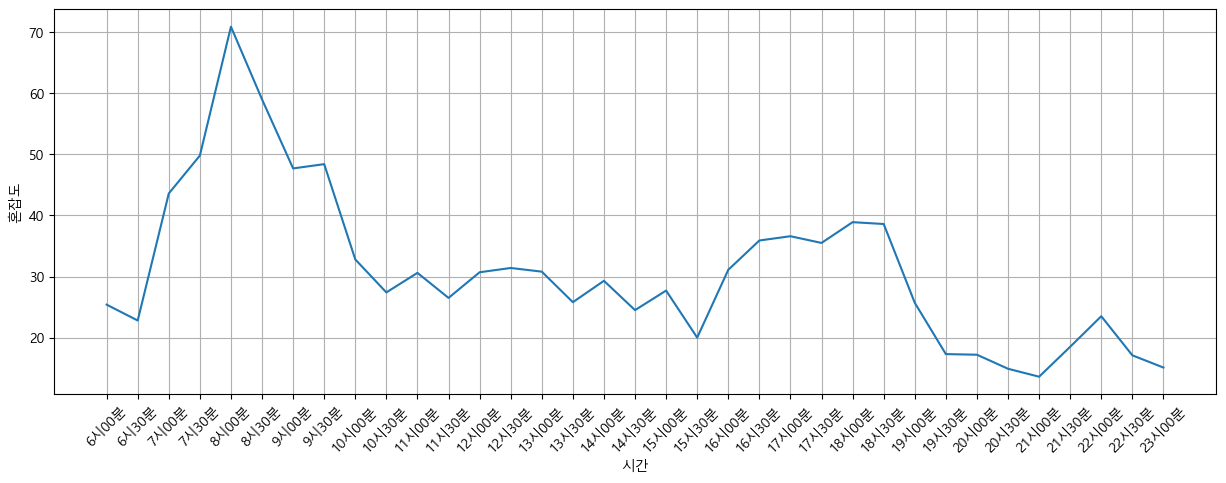

In [68]:
plt.figure(figsize=(15,5)) # 그래프의 가로, 세로 길이 설정
plt.plot(x, y)
plt.xticks(rotation=45)    # x축의 tick값들의 회전 각도 설정
plt.xlabel("시간")
plt.ylabel("혼잡도")
plt.grid()
plt.show()

- 출근 시간인 07:30 ~ 08:30까지 혼잡도가 최대치
- 퇴근 시간인 17:30 ~ 18:30까지의 혼잡도도 40% 가량

### 상선을 봤으니 하선도 봅시다

In [74]:
result_ = temp[(temp["요일구분"]=="평일") & (temp["호선"]==4) & (temp["상하구분"]=="하선")]
result_

,연번,요일구분,호선,역번호,출발역,상하구분,6시00분,6시30분,7시00분,7시30분,8시00분,8시30분,9시00분,9시30분,10시00분,10시30분,11시00분,11시30분,12시00분,12시30분,13시00분,13시30분,14시00분,14시30분,15시00분,15시30분,16시00분,16시30분,17시00분,17시30분,18시00분,18시30분,19시00분,19시30분,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분
237,238,평일,4,432,총신대입구,하선,28.5,17.0,22.6,34.3,37.3,32.9,24.7,23.2,21.1,17.4,22.2,22.8,26.1,23.2,29.4,24.4,27.5,22.8,35.9,34.6,43.0,45.8,54.6,53.4,55.1,75.1,46.8,32.8,25.5,29.3,25.7,30.8,36.0,30.1,26.6


In [79]:
y_ = result_.loc[:,"6시00분":].values.reshape(-1)
y_

array([28.5, 17. , 22.6, 34.3, 37.3, 32.9, 24.7, 23.2, 21.1, 17.4, 22.2,
       22.8, 26.1, 23.2, 29.4, 24.4, 27.5, 22.8, 35.9, 34.6, 43. , 45.8,
       54.6, 53.4, 55.1, 75.1, 46.8, 32.8, 25.5, 29.3, 25.7, 30.8, 36. ,
       30.1, 26.6])

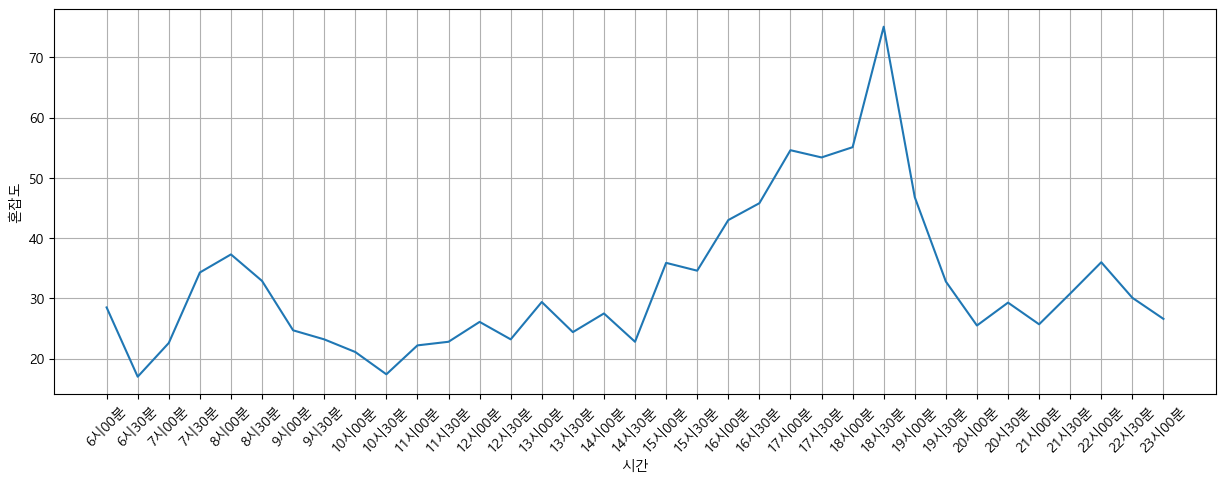

In [80]:
plt.figure(figsize=(15,5)) # 그래프의 가로, 세로 길이 설정
plt.plot(x, y_)
plt.xticks(rotation=45)    # x축의 tick값들의 회전 각도 설정
plt.xlabel("시간")
plt.ylabel("혼잡도")
plt.grid()
plt.show()

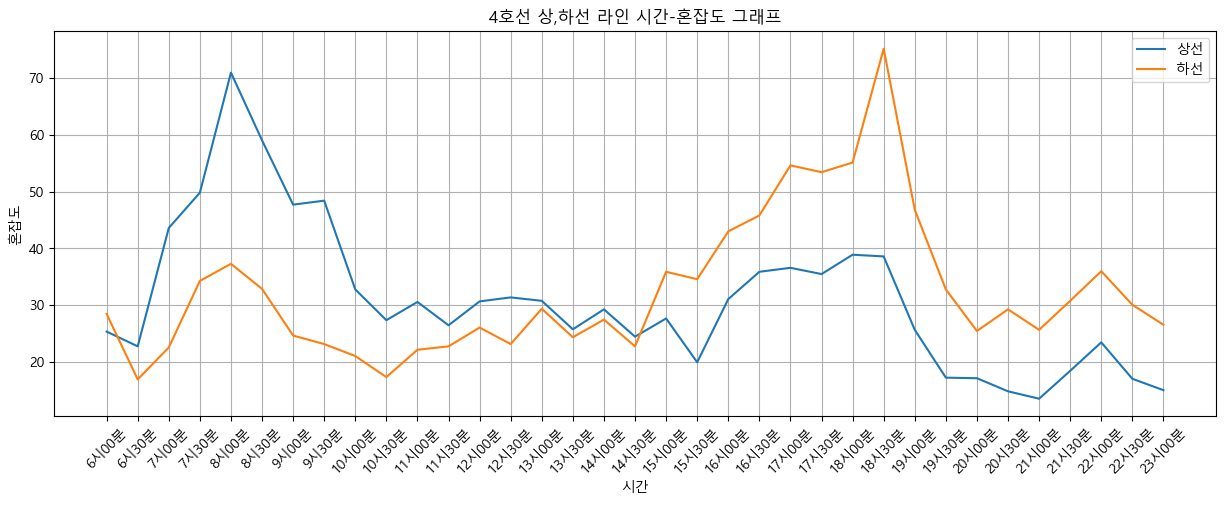

In [84]:
# 두개의 그래프를 합쳐보자
plt.figure(figsize=(15,5))

plt.plot(x, y, label="상선")  #상선
plt.plot(x, y_, label="하선") #하선

plt.xticks(rotation=45)
plt.title("4호선 상,하선 라인 시간-혼잡도 그래프")
plt.xlabel("시간")
plt.ylabel("혼잡도")
plt.legend()
plt.grid()
plt.show()

★결론★
- 총신대입구역에서 지하철을 사용하는 사람들은 직장 출,퇴근용으로 많이 이용
- 총신대입구역을 기준으로 보았을때 동작방면(상선)으로 출근하는 사람들이 많았고,
  사당방면(하선)으로 퇴근하는 사람들이 많았음! 
- 즉, 4호선만 봤을 경우 강ㄴ마권에 비해서 강북권에 직장이 많다고 유추를 해 볼 수 있음